In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

In [2]:
df = pd.read_csv("Employee.csv")     # If same folder
# If needed use full path:
# df = pd.read_csv(r"C:\Users\Yourname\Downloads\Employee.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (1470, 23)
  EmployeeID   FirstName  ... YearsSinceLastPromotion YearsWithCurrManager
0  3012-1A41    Leonelle  ...                       9                    7
1  CBCB-9C9D     Leonerd  ...                      10                    0
2  95D7-1CE9       Ahmed  ...                      10                    8
3  47A0-559B  Ermentrude  ...                      10                    0
4  42CC-040A       Stace  ...                       1                    6

[5 rows x 23 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   EmployeeID               1470 non-null   object
 1   FirstName                1470 non-null   object
 2   LastName                 1470 non-null   object
 3   Gender                   1470 non-null   object
 4   Age                      1470 non-null   int64 
 5   BusinessTravel           1

In [3]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 EmployeeID                 0
FirstName                  0
LastName                   0
Gender                     0
Age                        0
BusinessTravel             0
Department                 0
DistanceFromHome (KM)      0
State                      0
Ethnicity                  0
Education                  0
EducationField             0
JobRole                    0
MaritalStatus              0
Salary                     0
StockOptionLevel           0
OverTime                   0
HireDate                   0
Attrition                  0
YearsAtCompany             0
YearsInMostRecentRole      0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64


In [4]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

print("\nAfter Encoding:\n", df.head())


After Encoding:
    EmployeeID  FirstName  ...  YearsSinceLastPromotion  YearsWithCurrManager
0         275        793  ...                        9                     7
1        1158        794  ...                       10                     0
2         842         16  ...                       10                     8
3         402        418  ...                       10                     0
4         369       1182  ...                        1                     6

[5 rows x 23 columns]


In [7]:
# Make sure 'Attrition' exists in your dataset
if "Attrition" not in df.columns:
    raise ValueError("Target column 'Attrition' not found.")

x = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [13]:
y_pred = model.predict(X_test)


print("nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

nAccuracy: 0.8775510204081632

Classification Report:
               precision    recall  f1-score   support

           0       0.87      1.00      0.93       240
           1       0.95      0.35      0.51        54

    accuracy                           0.88       294
   macro avg       0.91      0.67      0.72       294
weighted avg       0.89      0.88      0.85       294



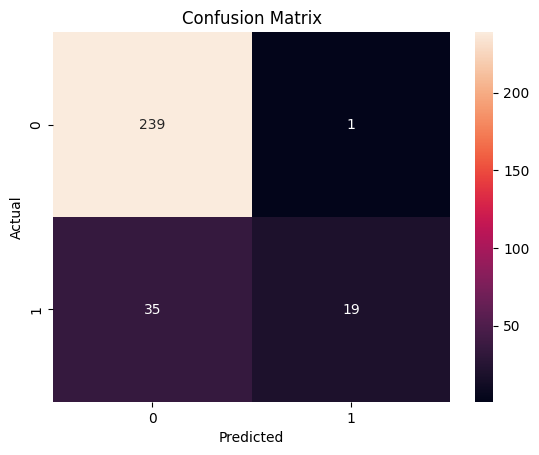

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)


plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

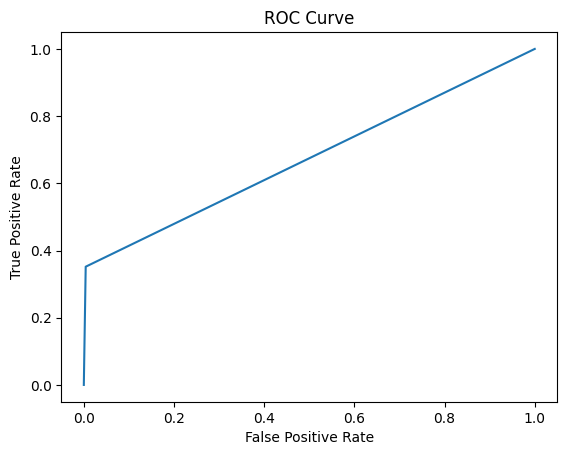

ROC AUC Score: 0.916280864197531


In [18]:
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

In [19]:
importances = model.feature_importances_
features = x.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)


print("\nFeature Importance:\n", feat_df)


Feature Importance:
                     Feature  Importance
17                 HireDate    0.150347
14                   Salary    0.080124
20  YearsSinceLastPromotion    0.075155
18           YearsAtCompany    0.073461
1                 FirstName    0.066786
0                EmployeeID    0.060095
4                       Age    0.058213
2                  LastName    0.056480
16                 OverTime    0.051595
7     DistanceFromHome (KM)    0.051022
21     YearsWithCurrManager    0.036413
11           EducationField    0.035651
19    YearsInMostRecentRole    0.030648
12                  JobRole    0.027523
9                 Ethnicity    0.026854
15         StockOptionLevel    0.026729
10                Education    0.022480
13            MaritalStatus    0.016698
5            BusinessTravel    0.016242
3                    Gender    0.013580
8                     State    0.012250
6                Department    0.011656
